<a href="https://colab.research.google.com/github/naamasarshalom-art/segmentation_cellpose/blob/main/2_manual_labeling_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Manual Nucleus Labeling Tool

This notebook is used to manually classify cropped nucleus images produced by the segmentation pipeline.

**Workflow:**
1. Run **Cell 1** once per session (setup)
2. Set your username, batch, and image number in **Cell 2**
3. Run **Cell 2** to launch the labeling widget
4. Use the buttons to classify each nucleus — the tool advances automatically

**Classes:**
- `good` — normal nucleus morphology
- `invaginated` — abnormal / invaginated nucleus
- `Unclassifiable` — nucleus present but morphology is unclear
- `trash` — segmentation artifact, out-of-focus, or empty crop

**Output:** each classified image is copied into the corresponding class folder inside the dataset directory.

## Cell 1 — Setup (run once per session)

In [1]:
# Mount Google Drive and import all required libraries
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import shutil
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import ipywidgets as widgets

from pathlib import Path
from IPython.display import display, clear_output


# ── Display helpers ────────────────────────────────────────────────────────

def normalize(x):
    """Normalize a 2D array to [0, 1] for display."""
    return (x - x.min()) / (x.max() - x.min() + 1e-8)


def show_overview(file_path):
    """
    Display the full microscopy image with bounding boxes.
    This is the overview image produced by the segmentation notebook.
    """
    img = imageio.imread(file_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Overview: {file_path.name}", fontsize=10)
    plt.show()


def show_nucleus(file_path):
    """
    Display a single cropped nucleus in three panels:
      - Channel 0 (blue channel, e.g. DAPI)
      - Channel 1 (red channel, e.g. secondary marker)
      - Merged RGB (red + blue)

    The crop is stored as an RGB JPEG where:
      - img[:, :, 2] = channel 0 (blue)
      - img[:, :, 0] = channel 1 (red)
    """
    img = imageio.imread(file_path)

    ch0 = normalize(img[:, :, 2])   # channel 0 → blue display
    ch1 = normalize(img[:, :, 0])   # channel 1 → red display

    # Build single-channel RGB images for individual display
    ch0_rgb = np.zeros((*img.shape[:2], 3))
    ch0_rgb[:, :, 2] = ch0

    ch1_rgb = np.zeros((*img.shape[:2], 3))
    ch1_rgb[:, :, 0] = ch1

    # Merged: both channels overlaid
    merged = np.zeros((*img.shape[:2], 3))
    merged[:, :, 0] = ch1
    merged[:, :, 2] = ch0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(ch0_rgb);  axes[0].set_title('Channel 0 (Blue)');  axes[0].axis('off')
    axes[1].imshow(ch1_rgb);  axes[1].set_title('Channel 1 (Red)');   axes[1].axis('off')
    axes[2].imshow(merged);   axes[2].set_title('Merged (Red + Blue)'); axes[2].axis('off')
    plt.suptitle(os.path.basename(file_path), fontsize=9, color='gray')
    plt.show()


print("✓ Setup complete — proceed to Cell 2")

Mounted at /content/drive
✓ Setup complete — proceed to Cell 2


## Cell 2 — Labeling widget (run for each image)

Set `SOURCE_DIR`, `DATASET_ROOT`, `BATCH`, and `IMAGE_NUMBER`, then run the cell.

Overview (all bounding boxes):


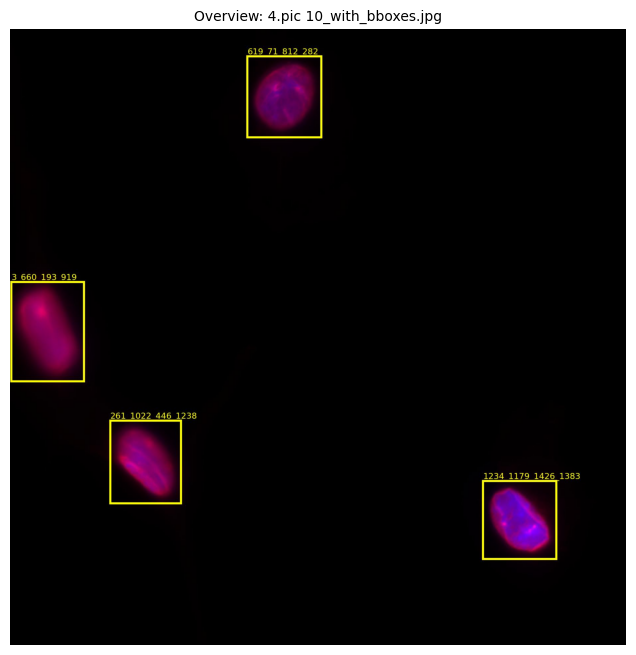

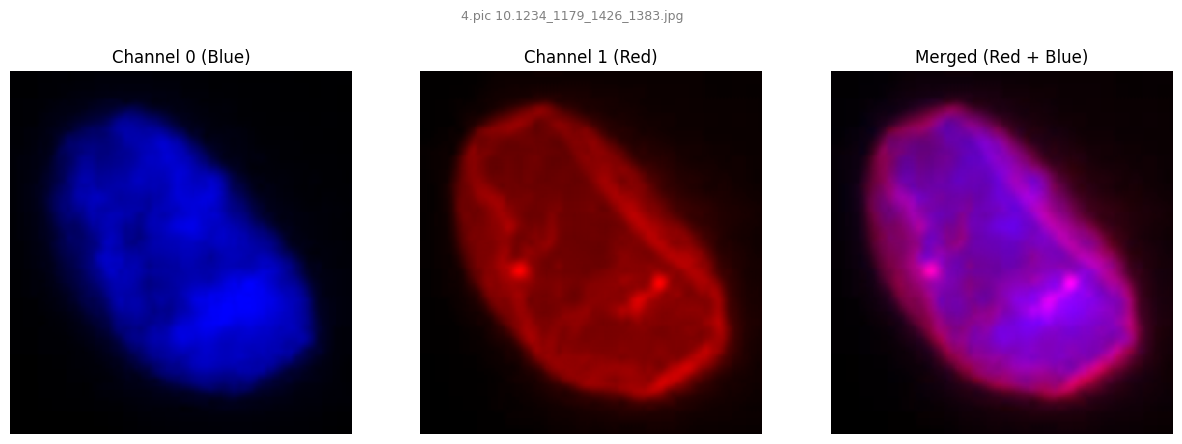

Nucleus 1 / 4


IntSlider(value=0, continuous_update=False, description='Nucleus:', max=3)

In [3]:
# ── Configuration ──────────────────────────────────────────────────────────
# Path to the folder containing segmentation results (crops + overview images)
SOURCE_DIR   = "/content/drive/MyDrive/model_nuc/nuclei_results_batch_4"  # ← change per batch

# Path to the root folder where labeled images will be saved (one subfolder per class)
DATASET_ROOT = "/content/drive/MyDrive/model_nuc/dataset v.0.4"  # ← change to your dataset path

BATCH        = "4"   # @param ["1", "2", "3", "4"]  — must match the batch prefix in filenames
IMAGE_NUMBER = 10     # @param {type:"integer"}       — which microscopy image to label

SOURCE_DIR = Path(SOURCE_DIR)

# ── Collect crops for this image number ───────────────────────────────────
# Filename convention: {batch}.pic {number}<anything>.jpg
# The overview (with_bboxes) is separated from individual crops.
pattern = re.compile(rf"^{BATCH}\.pic {IMAGE_NUMBER}(?!\d).*\.jpg$")

all_matching = [
    f for f in SOURCE_DIR.iterdir()
    if f.is_file() and pattern.match(f.name)
]

if not all_matching:
    raise FileNotFoundError(
        f"No files found for batch {BATCH}, image {IMAGE_NUMBER} in {SOURCE_DIR}"
    )

# The overview image (contains 'with_bboxes' in its name)
overview_images = [f for f in all_matching if "with_bboxes" in f.name.lower()]
overview_path   = overview_images[0] if overview_images else None

# Individual nucleus crops (everything else), sorted naturally
crops = sorted([f for f in all_matching if "with_bboxes" not in f.name.lower()])

print(f"Batch:         {BATCH}  |  Image: {IMAGE_NUMBER}")
print(f"Nucleus crops: {len(crops)}")
print(f"Output root:   {DATASET_ROOT}")


# ── Widget state ───────────────────────────────────────────────────────────
current_idx = [0]   # wrapped in list so closures can mutate it


# ── Display current nucleus ────────────────────────────────────────────────
def show_current():
    clear_output(wait=True)

    # Show overview once at the top for spatial context
    if overview_path:
        print("Overview (all bounding boxes):")
        show_overview(overview_path)

    # Show the current crop
    show_nucleus(crops[current_idx[0]])

    print(f"Nucleus {current_idx[0] + 1} / {len(crops)}")
    display(slider, button_row)


# ── Classification logic ───────────────────────────────────────────────────
def classify(label):
    """
    Copy the current crop into the corresponding class folder,
    then advance to the next nucleus automatically.
    """
    src  = crops[current_idx[0]]
    dest = Path(DATASET_ROOT) / label
    dest.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dest / src.name)
    print(f"✓ Saved as '{label}': {src.name}")

    # Advance to next crop
    if current_idx[0] < len(crops) - 1:
        current_idx[0] += 1
        slider.value = current_idx[0]
    else:
        print("\n🎉 All nuclei in this image have been classified!")

    show_current()


# ── Slider — manual navigation ─────────────────────────────────────────────
slider = widgets.IntSlider(
    value=0, min=0, max=len(crops) - 1, step=1,
    description='Nucleus:', continuous_update=False
)

def on_slider(change):
    current_idx[0] = change['new']
    show_current()

slider.observe(on_slider, names='value')


# ── Buttons ────────────────────────────────────────────────────────────────
CLASSES = ["good", "invaginated", "Unclassifiable", "trash"]

BUTTON_COLORS = {
    "good":           "success",
    "invaginated":    "danger",
    "Unclassifiable": "warning",
    "trash":          "info",
}

def make_button(label):
    btn = widgets.Button(
        description=label,
        button_style=BUTTON_COLORS.get(label, "")
    )
    btn.on_click(lambda _: classify(label))
    return btn

button_row = widgets.HBox([make_button(c) for c in CLASSES])


# ── Launch ─────────────────────────────────────────────────────────────────
show_current()